In [ ]:
from neuralhydrology.utils.config import Config
from neuralhydrology.utils.DCFE_utils import get_dcfe_params
from neuralhydrology.datautils import utils
from pathlib import Path
import torch
from neuralhydrology.nh_run import start_run
import pandas as pd
import pickle

# CAMELS Trained Model Result Comaprison

## Average vs. Dynamic

In [18]:
dynamic_path = Path("runs/EXP1_CAMELS_noSnow_HPC_Dynamic_2208_161237")
average_path = Path("runs/EXP1_CAMELS_noSnow_HPC_Average_2508_103802")

dynamic_metric = pd.read_csv(dynamic_path / "test" / "model_epoch030" / "test_metrics.csv")
average_metric = pd.read_csv(average_path / "test" / "model_epoch030" / "test_metrics.csv")

In [22]:
import pickle
with open(average_path / "test" / "model_epoch030" / 'test_results.p', "rb") as f:
    data = pickle.load(f)

In [28]:
data['09484600']

{'1D': {'xr': <xarray.Dataset> Size: 3MB
  Dimensions:         (date: 1097, time_step: 365)
  Coordinates:
    * date            (date) datetime64[ns] 9kB 1997-09-30 ... 2000-09-30
    * time_step       (time_step) int64 3kB -364 -363 -362 -361 ... -3 -2 -1 0
  Data variables:
      QObs(mm/d)_obs  (date, time_step) float32 2MB 0.00184 0.001696 ... 0.001199
      QObs(mm/d)_sim  (date, time_step) float32 2MB 0.0 0.0 0.0 ... 0.0 0.0 0.0,
  'NSE': 0.05071115493774414}}

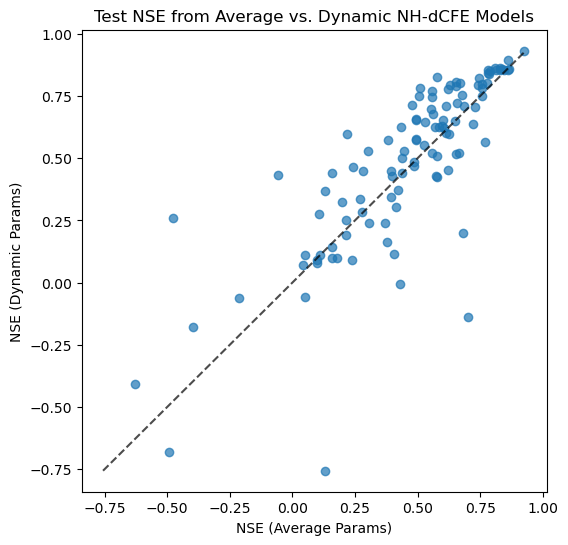

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(average_metric["NSE"], dynamic_metric["NSE"], alpha=0.7)

plt.xlabel("NSE (Average Params)")
plt.ylabel("NSE (Dynamic Params)")
plt.title("Test NSE from Average vs. Dynamic NH-dCFE Models")

# Add 1:1 line for reference
lims = [
    min(average_metric["NSE"].min(), dynamic_metric["NSE"].min()),
    max(average_metric["NSE"].max(), dynamic_metric["NSE"].max())
]
plt.plot(lims, lims, 'k--', alpha=0.7)

plt.show()

# Examine Parameters
We want use data and the weights to simulate getting back CFE parameters, this will show that we have the framework to get CFE params for NextGen. This will help us examine if the dynamic method and average trained method arrive at similar parameter space, and if their performance differ if averaged. We have the following training configuration.

static_attributes:
- elev_mean
- slope_mean
- clay_frac
- silt_frac
- sand_frac
- organic_frac
- water_frac
- frac_snow
- pet_mean
- aridity

dynamic_inputs:
- PRCP(mm/day)_nldas
- SRAD(W/m2)_nldas
- Tmax(C)_nldas
- Tmin(C)_nldas
- Vp(Pa)_nldas

dynamic_conceptual_inputs:
- PRCP(mm/day)_nldas_copy1
- Tmin(C)_nldas_copy1
- Tmax(C)_nldas_copy1
- SRAD(W/m2)_nldas_copy1

We will validate this result is correct from looking at Turkey Creek at Byromville, GA (Basin ID: 02349900) (in sample). 

In [10]:
# First, load the trained weights from the dynamic model, and look at the dimensions
dynamic_weights_path = dynamic_path/"model_epoch030.pt"
dynamic_weights = torch.load(dynamic_weights_path, map_location="cpu")
# examine the keys in the state dict
for key in dynamic_weights.keys():
    print(key, dynamic_weights[key].shape)

lstm.weight_ih_l0 torch.Size([80, 15])
lstm.weight_hh_l0 torch.Size([80, 20])
lstm.bias_ih_l0 torch.Size([80])
lstm.bias_hh_l0 torch.Size([80])
linear.weight torch.Size([10, 20])
linear.bias torch.Size([10])


Looks like input size is 15 (dynamic + static inputs to LSTM) and output size is 10 (CFE parameters predicted via LSTM). What order is the dynamic & static inputs in?

AttributeError: 'collections.OrderedDict' object has no attribute 'shape'